# Customer 360 — Churn Prediction

This notebook develops and evaluates machine learning models to predict customer churn. Multiple classification algorithms are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC, followed by hyperparameter tuning of the selected Random Forest model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
import os
import joblib
os.makedirs("../models", exist_ok=True)

In [2]:
df = pd.read_csv("../Dataset/customer_360_ml_workshop.csv")

## Data Preprocessing

The train/test split is performed **before** any model fitting. A reusable `ColumnTransformer` handles:

- numerical variables: median imputation → standardization
- categorical variables: most-frequent imputation → one-hot encoding
- `handle_unknown="ignore"` for unseen categories

The transformer is placed inside model pipelines, so each model learns preprocessing only from its training data.

In [3]:
x = df.drop(columns=["CustomerID", "Churn", "Future12MRevenueEGP"])
y_classification = df["Churn"].map({"No": 0, "Yes": 1})

In [4]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x, y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

In [5]:
numeric_features = x.select_dtypes(include='number').columns.tolist()
categorical_features = x.select_dtypes(include='str').columns.tolist()

In [6]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

In [7]:
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore']
Categorical features: ['Region', 'ContractType', 'InternetType', 'PaperlessBilling', 'AutoPay']


## Churn Classification

In [8]:
classification_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

classification_pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in classification_models.items()
}

In [9]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classification_results = []

for name, model in classification_pipelines.items():
    model.fit(x_train_c, y_train_c)
    pred = model.predict(x_test_c)
    prob = model.predict_proba(x_test_c)[:, 1]

    cv_f1 = cross_val_score(model, x_train_c, y_train_c,cv=cv_class, scoring="f1", n_jobs=-1).mean()

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred, zero_division=0),
        "Recall": recall_score(y_test_c, pred, zero_division=0),
        "F1": f1_score(y_test_c, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_c, prob),
        "CV F1": cv_f1
    })

classification_results = pd.DataFrame(classification_results).sort_values("CV F1", ascending=False)

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1
5,Naive Bayes,0.750,0.374,0.560,0.449,0.761,0.436
2,Decision Tree,0.710,0.259,0.321,0.287,0.559,0.310
6,Gradient Boosting,0.808,0.412,0.128,0.196,0.732,0.296
0,Logistic Regression,0.813,0.459,0.156,0.233,0.764,0.260
1,K-Nearest Neighbors,0.792,0.340,0.156,0.214,0.597,0.229
3,Random Forest,0.822,0.542,0.119,0.195,0.718,0.162
4,Support Vector Machine,0.825,0.700,0.064,0.118,0.708,0.085


### Random Forest Tuning

In [10]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring="f1",
    cv=cv_class,
    n_jobs=-1
)

rf_grid.fit(x_train_c, y_train_c)
rf_tuned = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

Best Random Forest parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [11]:
rf_pred = rf_tuned.predict(x_test_c)
rf_prob = rf_tuned.predict_proba(x_test_c)[:, 1]

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test_c, rf_pred),
        precision_score(y_test_c, rf_pred, zero_division=0),
        recall_score(y_test_c, rf_pred, zero_division=0),
        f1_score(y_test_c, rf_pred, zero_division=0),
        roc_auc_score(y_test_c, rf_prob)
    ]
})

rf_metrics.round(3)

,Metric,Score
0,Accuracy,0.685
1,Precision,0.332
2,Recall,0.725
3,F1,0.455
4,ROC-AUC,0.754


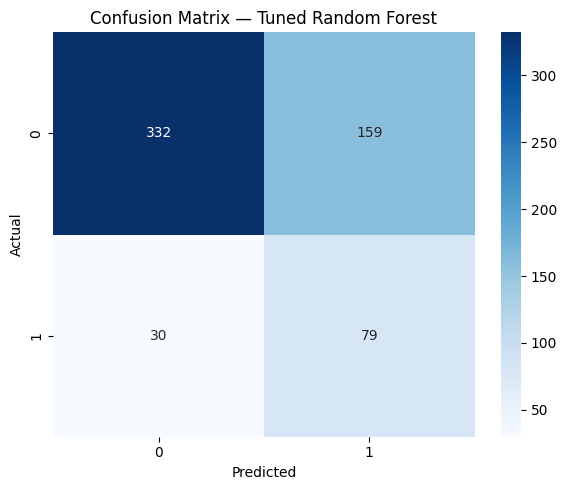

In [12]:
cm = confusion_matrix(y_test_c, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()

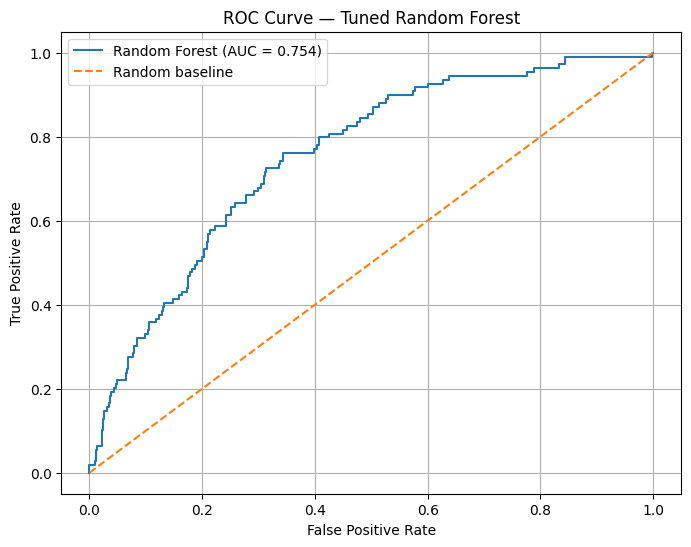

In [13]:
fpr, tpr, _ = roc_curve(y_test_c, rf_prob)
roc_auc = roc_auc_score(y_test_c, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest")
plt.legend()
plt.grid()
plt.show()

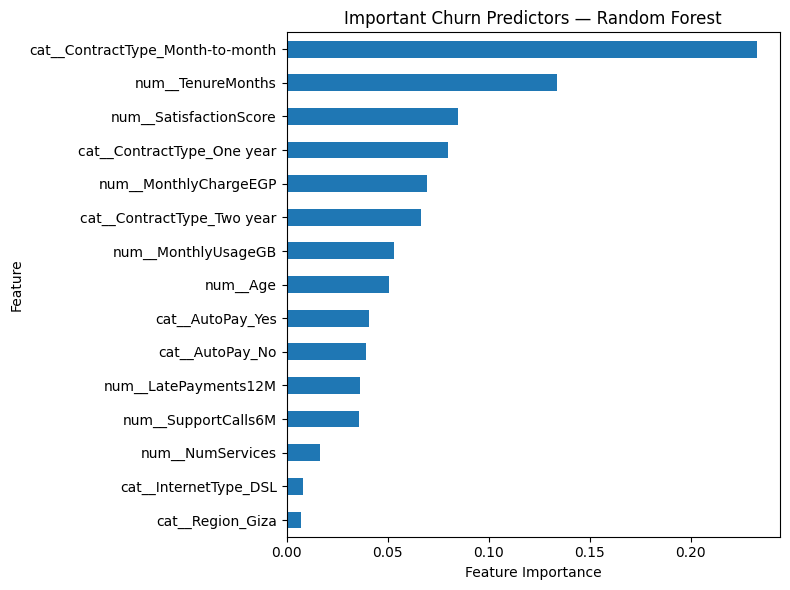

,Importance
cat__ContractType_Month-to-month,0.2325
num__TenureMonths,0.1336
num__SatisfactionScore,0.0846
cat__ContractType_One year,0.0799
num__MonthlyChargeEGP,0.0697
cat__ContractType_Two year,0.0666
num__MonthlyUsageGB,0.0532
num__Age,0.0507
cat__AutoPay_Yes,0.0406
cat__AutoPay_No,0.0392


In [14]:
feature_names = rf_tuned.named_steps["preprocessor"].get_feature_names_out()
importance = rf_tuned.named_steps["model"].feature_importances_

important_features = pd.Series(importance, index=feature_names).sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(8, 6))
important_features.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Important Churn Predictors — Random Forest")
plt.tight_layout()
plt.show()

important_features.sort_values(ascending=False).to_frame("Importance").round(4)

### Enhanced Churn Classification — Grid Search + SMOTENC

SMOTENC is included inside the cross-validation pipeline so oversampling is performed only on each training fold. This avoids leakage from synthetic observations into validation folds.

Categorical variables are temporarily ordinal-encoded for SMOTENC, then one-hot encoded after oversampling. Numerical variables are imputed before SMOTENC and standardized afterward.

In [15]:
numeric_pre_smote = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pre_smote = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

pre_smote = ColumnTransformer([
    ("num", numeric_pre_smote, numeric_features),
    ("cat", categorical_pre_smote, categorical_features)
])

num_indices = list(range(len(numeric_features)))
cat_indices = list(range(len(numeric_features), len(numeric_features) + len(categorical_features)))

post_smote = ColumnTransformer([
    ("num", StandardScaler(), num_indices),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_indices)
])

print("SMOTENC categorical indices:", cat_indices)

SMOTENC categorical indices: [8, 9, 10, 11, 12]


In [16]:
grid_models = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=2000),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__class_weight": [None, "balanced"]
        }
    },

    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Support Vector Machine": {
        "model": SVC(random_state=42, probability=True),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    },

    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "model__var_smoothing": np.logspace(0, -9, 5)
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

In [17]:
tuned_classification_models = {}
tuned_classification_results = []

for name, info in grid_models.items():

    pipeline = ImbPipeline([
        ("pre_smote", pre_smote),
        ("smote", SMOTENC(categorical_features=cat_indices, random_state=42)),
        ("post_smote", post_smote),
        ("model", info["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=info["params"],
        scoring="f1",
        cv=cv_class,
        n_jobs=-1
    )

    grid.fit(x_train_c, y_train_c)

    best_model = grid.best_estimator_
    tuned_classification_models[name] = best_model

    pred = best_model.predict(x_test_c)
    prob = best_model.predict_proba(x_test_c)[:, 1]

    tuned_classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred, zero_division=0),
        "Recall": recall_score(y_test_c, pred, zero_division=0),
        "F1": f1_score(y_test_c, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_c, prob),
        "CV Best F1": grid.best_score_
    })

tuned_classification_results = pd.DataFrame(tuned_classification_results).sort_values("CV Best F1", ascending=False)

tuned_classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Best F1
0,Logistic Regression,0.695,0.325,0.633,0.430,0.753,0.456
4,Support Vector Machine,0.675,0.325,0.734,0.451,0.752,0.455
3,Random Forest,0.702,0.325,0.596,0.421,0.740,0.453
5,Naive Bayes,0.610,0.294,0.817,0.432,0.728,0.421
6,Gradient Boosting,0.782,0.394,0.376,0.385,0.743,0.404
1,K-Nearest Neighbors,0.567,0.225,0.569,0.323,0.615,0.398
2,Decision Tree,0.733,0.353,0.560,0.433,0.722,0.388


### Confusion Matrices — All Tuned Classification Models

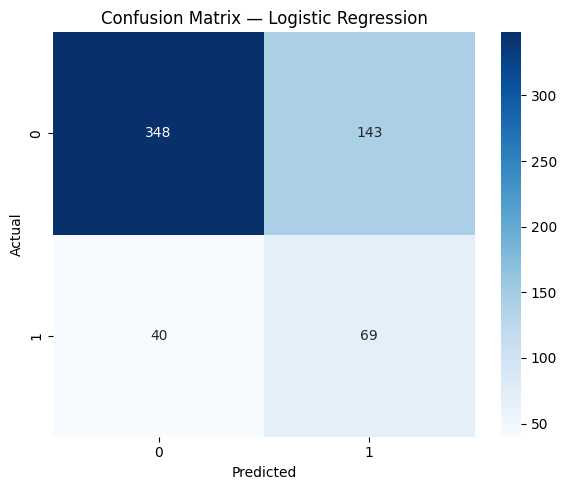

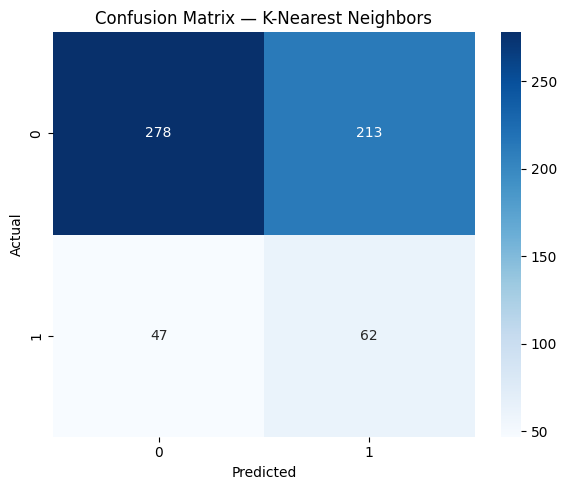

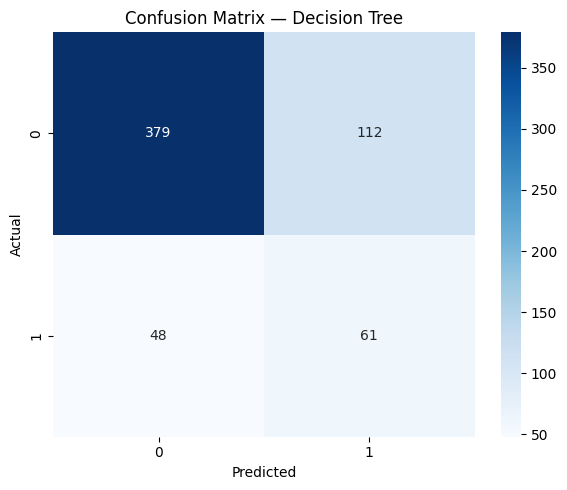

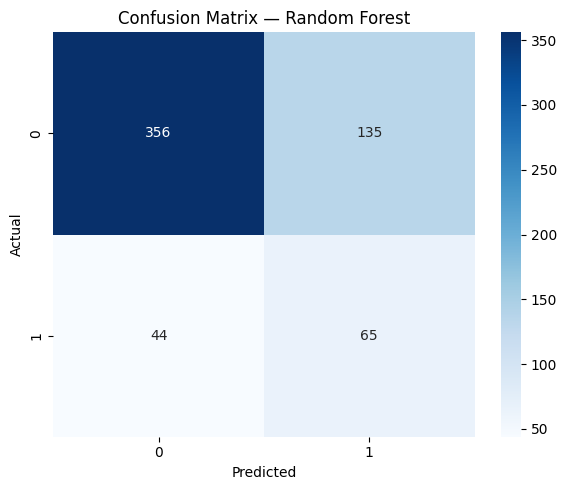

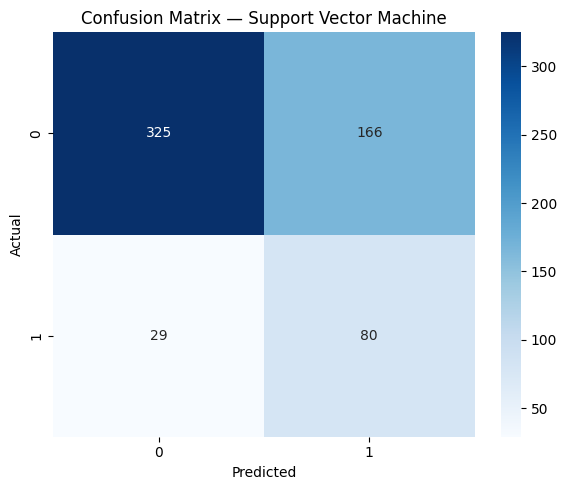

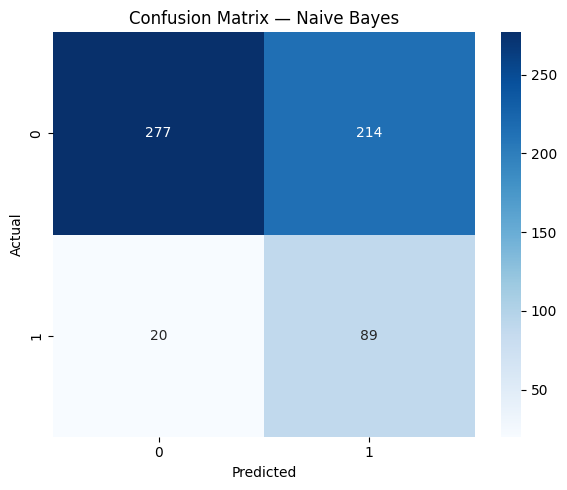

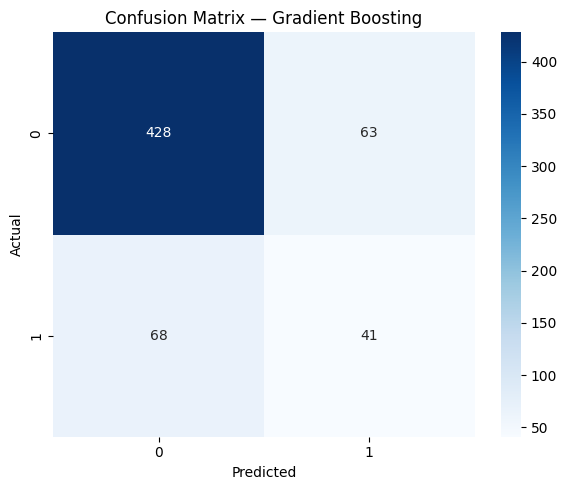

In [18]:
for name, model in tuned_classification_models.items():
    pred = model.predict(x_test_c)
    cm = confusion_matrix(y_test_c, pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

### ROC Curve — All Tuned Classification Models

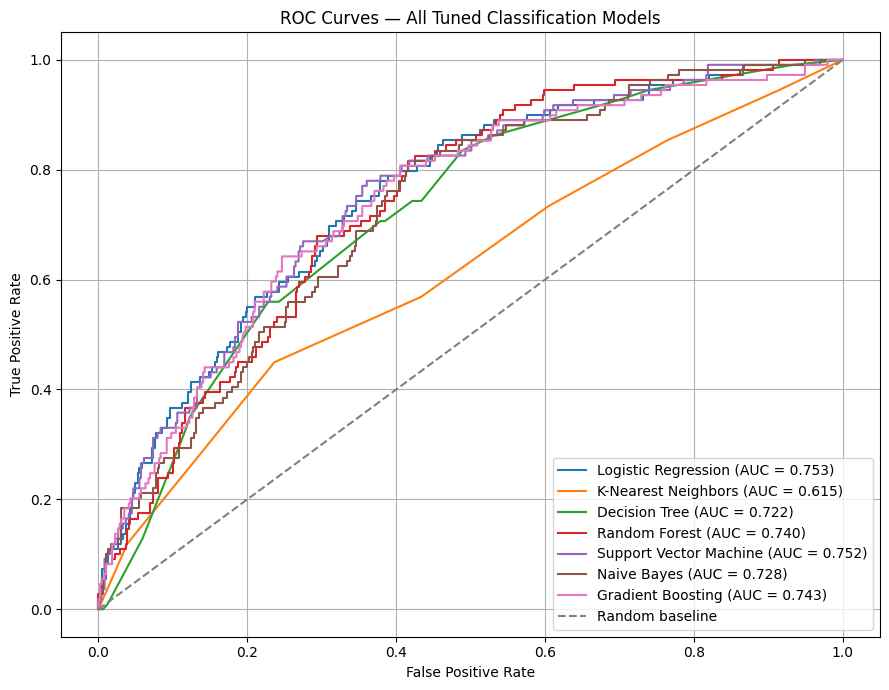

In [19]:
plt.figure(figsize=(9, 7))

for name, model in tuned_classification_models.items():
    prob = model.predict_proba(x_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, prob)
    roc_auc = roc_auc_score(y_test_c, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Tuned Classification Models")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Final Tuned Random Forest — Important Churn Predictors

In [20]:
rf_tuned = tuned_classification_models["Random Forest"]

rf_pred = rf_tuned.predict(x_test_c)
rf_prob = rf_tuned.predict_proba(x_test_c)[:, 1]

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test_c, rf_pred),
        precision_score(y_test_c, rf_pred, zero_division=0),
        recall_score(y_test_c, rf_pred, zero_division=0),
        f1_score(y_test_c, rf_pred, zero_division=0),
        roc_auc_score(y_test_c, rf_prob)
    ]
})

rf_metrics.round(3)

,Metric,Score
0,Accuracy,0.702
1,Precision,0.325
2,Recall,0.596
3,F1,0.421
4,ROC-AUC,0.740


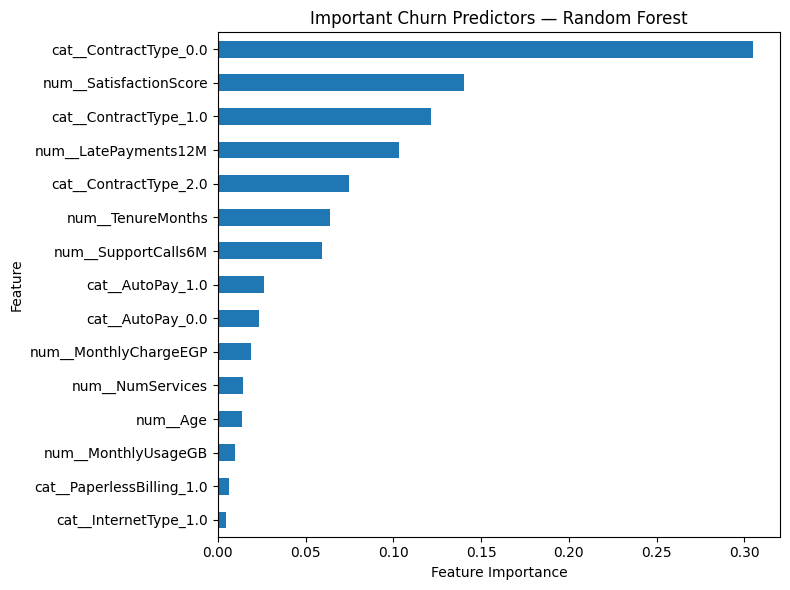

,Importance
cat__ContractType_0.0,0.3050
num__SatisfactionScore,0.1405
cat__ContractType_1.0,0.1215
num__LatePayments12M,0.1032
cat__ContractType_2.0,0.0745
num__TenureMonths,0.0641
num__SupportCalls6M,0.0594
cat__AutoPay_1.0,0.0263
cat__AutoPay_0.0,0.0237
num__MonthlyChargeEGP,0.0187


In [21]:
feature_names = numeric_features + categorical_features

importance = rf_tuned.named_steps["model"].feature_importances_

feature_names = rf_tuned.named_steps["post_smote"].get_feature_names_out(feature_names)

important_features = pd.Series(importance,index=feature_names).sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(8, 6))
important_features.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Important Churn Predictors — Random Forest")
plt.tight_layout()
plt.show()

important_features.sort_values(ascending=False).to_frame("Importance").round(4)

### Churn Threshold Analysis

A lower threshold catches more potential churners, while a higher threshold creates a smaller, more selective outreach group. The threshold should therefore be chosen using the business cost of missed churn versus unnecessary retention contact.

In [22]:
threshold_rows = []

for threshold in [0.35, 0.50, 0.70]:
    pred_threshold = (rf_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Predicted Churn %": pred_threshold.mean(),
        "Precision": precision_score(y_test_c, pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_c, pred_threshold, zero_division=0),
        "F1": f1_score(y_test_c, pred_threshold, zero_division=0)
    })

pd.DataFrame(threshold_rows).round(3)

,Threshold,Predicted Churn %,Precision,Recall,F1
0,0.35,0.517,0.290,0.826,0.430
1,0.50,0.333,0.325,0.596,0.421
2,0.70,0.053,0.406,0.119,0.184


In [23]:
joblib.dump(rf_tuned, "../models/churn_model.pkl")

['../models/churn_model.pkl']